# CPI Backtest Demo

End-to-end backtest of an AutoARIMA baseline on the CPI All-items Canada
12-month ahead forecasting task.

**Task:** Predict Canada CPI All-items (2002=100) exactly 12 months ahead.  
**Origins:** January and July, 2002–2026 (twice per year).  
**Predictor:** AutoARIMA (Darts), probabilistic via 500 Monte Carlo samples.  
**Score:** CRPS (lower is better).

## Prerequisites

Populate the local data cache before running this notebook:

```bash
uv run python scripts/fetch_cpi.py
```

In [19]:
import sys
from pathlib import Path

import yaml


# Ensure the workspace root is on sys.path when run from this directory.
repo_root = Path().resolve().parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

## 1. Register CPI All-items

In [20]:
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters import StatCanAdapter


CACHE_DIR = repo_root / "data" / "statcan"

svc = DataService()

adapter = StatCanAdapter(
    table_id="18-10-0004-11",
    member_filter={"GEO": "Canada", "Products and product groups": "All-items"},
    cache_dir=CACHE_DIR,
)
meta = SeriesMetadata(
    series_id="cpi_all_items_canada",
    description="CPI All-items, Canada (2002=100)",
    source="StatCan table 18-10-0004-11",
    units="Index 2002=100",
    frequency="MS",
)
svc.register("cpi_all_items_canada", adapter, meta)
svc.summary()

,series_id,description,source,units,frequency,n_obs,start,end
0,cpi_all_items_canada,"CPI All-items, Canada (2002=100)",StatCan table 18-10-0004-11,Index 2002=100,MS,1346,1914-01-01,2026-02-01


## 2. Load the reference spec

In [21]:
from aieng.forecasting.evaluation import BacktestSpec


spec_path = repo_root / "reference_specs" / "cpi_allitems_12m.yaml"
with spec_path.open() as f:
    spec = BacktestSpec.model_validate(yaml.safe_load(f))

origins = spec.origins()
print(f"Task:    {spec.task.task_id}")
print(f"Horizon: {spec.task.horizon} months")
print(f"Origins: {len(origins)} ({origins[0].date()} → {origins[-1].date()})")
print(f"Warmup:  {spec.warmup} observations")

Task:    cpi_all_items_canada_12m
Horizon: 12 months
Origins: 53 (2000-01-01 → 2026-01-01)
Warmup:  24 observations


## 3. Instantiate the predictor

In [22]:
from aieng.forecasting.evaluation import ARIMAPredictor


predictor = ARIMAPredictor(num_samples=500)
print(f"Predictor: {predictor.predictor_id}")

Predictor: arima_auto


## 4. Run the backtest

This cell fits AutoARIMA once per forecast origin — expect it to take a few minutes.

In [23]:
from aieng.forecasting.evaluation import backtest


results = backtest(predictor=predictor, spec=spec, data_service=svc)

print(f"Predictor:        {results.predictor_id}")
print(f"Origins scored:   {len(results.predictions)}")
print(f"Origins skipped:  {results.skipped_origins}")
print(f"Mean CRPS:        {results.mean_crps:.4f}")

Predictor:        arima_auto
Origins scored:   51
Origins skipped:  2
Mean CRPS:        1.1525


## 5. Per-origin scores

In [24]:
import pandas as pd


score_df = pd.DataFrame(
    {
        "origin": [p.as_of.date() for p in results.predictions],
        "forecast_date": [p.forecast_date.date() for p in results.predictions],
        "point_forecast": [p.payload.point_forecast for p in results.predictions],
        "crps": results.scores,
    }
)
score_df

,origin,forecast_date,point_forecast,crps
0,2000-01-01,2001-01-01,95.175351,0.711981
1,2000-07-01,2001-07-01,98.161667,0.243850
2,2001-01-01,2002-01-01,99.160661,1.104593
3,2001-07-01,2002-07-01,102.195295,1.202178
4,2002-01-01,2003-01-01,98.296808,3.247722
5,2002-07-01,2003-07-01,102.345621,0.240381
6,2003-01-01,2004-01-01,103.492721,0.233236
7,2003-07-01,2004-07-01,104.772037,0.230776
8,2004-01-01,2005-01-01,105.101990,0.223562
9,2004-07-01,2005-07-01,107.704113,0.370655


## 6. Predictions vs. actuals with 80% credible intervals

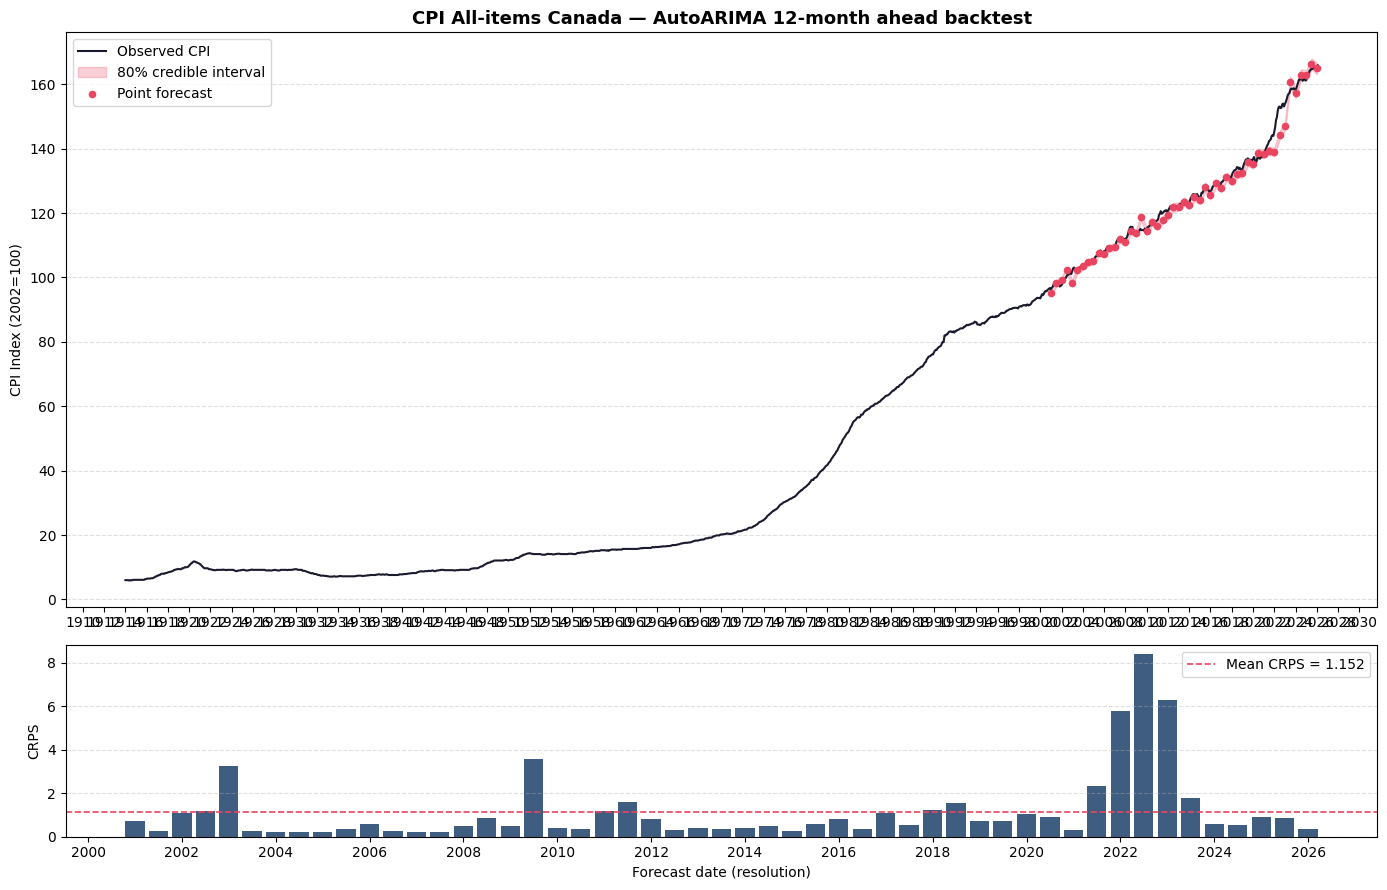

In [25]:
from datetime import datetime, timezone

import matplotlib.dates as mdates
import matplotlib.pyplot as plt


# Retrieve the full observed series for plotting.
full_series = svc.get_series(
    "cpi_all_items_canada",
    as_of=datetime.now(tz=timezone.utc).replace(tzinfo=None),
)

forecast_dates = [p.forecast_date for p in results.predictions]
point_forecasts = [p.payload.point_forecast for p in results.predictions]
q10 = [p.payload.quantiles.get(0.10, p.payload.point_forecast) for p in results.predictions]
q90 = [p.payload.quantiles.get(0.90, p.payload.point_forecast) for p in results.predictions]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]})

# --- Top panel: observed series + forecasts ---
ax = axes[0]
ax.plot(full_series["timestamp"], full_series["value"], color="#1a1a2e", linewidth=1.5, label="Observed CPI")
ax.fill_between(forecast_dates, q10, q90, alpha=0.25, color="#e94560", label="80% credible interval")
ax.scatter(forecast_dates, point_forecasts, color="#e94560", s=20, zorder=5, label="Point forecast")
ax.set_title("CPI All-items Canada — AutoARIMA 12-month ahead backtest", fontsize=13, fontweight="bold")
ax.set_ylabel("CPI Index (2002=100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Bottom panel: CRPS over time ---
ax2 = axes[1]
ax2.bar(forecast_dates, results.scores, width=150, color="#0f3460", alpha=0.8)
ax2.axhline(
    results.mean_crps, color="#e94560", linestyle="--", linewidth=1.2, label=f"Mean CRPS = {results.mean_crps:.3f}"
)
ax2.set_ylabel("CRPS")
ax2.set_xlabel("Forecast date (resolution)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

## 7. Serialize the result to YAML

The `BacktestResult` is a Pydantic model — it can be serialized to YAML and
persisted alongside the predictor implementation, passed to a downstream
agent as structured context, or used as a submission artefact.

In [ ]:
result_dict = results.model_dump(mode="json")
result_yaml = yaml.dump(result_dict, default_flow_style=False, allow_unicode=True)

# Preview the first ~40 lines.
print("\n".join(result_yaml.splitlines()[:40]))
print("...")